In [10]:
# Преоразовать существующий код для распознавания последовательности рукописных символов в текст.
# Написать генератор произвольной последовательности рукописных символов.

# ГЕНЕРАЦИЯ НАБОРА ДАННЫХ
# Сгенерировать набор текстовых строк из допустимых символов.
# Каждому набору поставить в соотвествие массив изоражений соответствующих символов.
# Добавить пробелы для разделения слов, символы пробелов не использовать во время классификации.

# КЛАССИФИКАЦИЯ (k ближайших соседей) (пример AIM practice 2)
# Часть символов оставить для обучения классификатора . Остальные  классифицировать
# по аналогии с примером mnist с прошлого занятия. Т.е. преобразовывать изображение в вектор.
# Выбрать оптимальный классификатор в зависимости от k- количество соседей.
# Метрика для измерения точности классификации, и выбора оптимального классификатора относительно параметра k - accuracy.

# РАСПОЗНАВАНИЕ
# заменить inf_net на последовательное применение следующих шагов:
# 1. генерация изображения с последовательностью символов
# 2. Выделение объектов оставляете как есть.
# 3. Примернить k-nn для решения задачи классификации. 
# 4. Вывести результат

In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import random
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

In [22]:
# отцентрированние на белом фоне символа фикс размера 45 на 45
def format_character(img, size=45):
    _, binary = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    points = cv2.findNonZero(binary)
    if points is None:
        return np.full((size, size), 255, np.uint8)
    x, y, w, h = cv2.boundingRect(points)
    if w == 0 or h == 0:
        return np.full((size, size), 255, np.uint8)
    char_crop = binary[y:y+h, x:x+w]
    ratio = min(size / w, size / h)
    new_w = int(w * ratio)
    new_h = int(h * ratio)
    scaled = cv2.resize(char_crop, (new_w, new_h), interpolation=cv2.INTER_AREA)
    result = np.full((size, size), 255, np.uint8)
    offset_x = (size - new_w) // 2
    offset_y = (size - new_h) // 2
    result[offset_y:offset_y+new_h, offset_x:offset_x+new_w] = scaled
    return result

In [23]:
# генерация случайных математических выражений
class SequenceBuilder:
    def __init__(self, data_path):
        self.data_path = data_path
        self.symbols = []
        for folder in os.listdir(data_path):
            full_path = os.path.join(data_path, folder)
            if os.path.isdir(full_path):
                if folder == 'X': 
                    self.symbols.append('x')
                elif folder == 'times': 
                    self.symbols.append('*')
                else: 
                    self.symbols.append(folder)
        print("Доступные символы:", self.symbols)

    def load_char_image(self, char):
        folder = 'X' if char == 'x' else 'times' if char == '*' else char
        char_path = os.path.join(self.data_path, folder)
        if not os.path.exists(char_path):
            return None
        image_files = [f for f in os.listdir(char_path) 
                      if f.lower().endswith(('.png','.jpg','.bmp','.jpeg'))]
        image_files.sort()
        test_start = int(len(image_files) * 0.8)
        test_files = image_files[test_start:]
        if not test_files:
            return None
        img = cv2.imread(os.path.join(char_path, random.choice(test_files)), cv2.IMREAD_GRAYSCALE)
        if img is not None:
            img = format_character(img)
        return img

    def build_sequence(self, length=10):
        text = ''
        char_images = []
        for _ in range(length):
            char = random.choice(self.symbols)
            img = self.load_char_image(char)
            if img is not None:
                text += char
                char_images.append(img)
        return text, char_images

In [24]:
# одно изображение, представляющее последовательность символов
def merge_characters(char_images, gap=20):
    if not char_images:
        return None
    width = sum(img.shape[1] for img in char_images) + gap * (len(char_images) - 1)
    height = max(img.shape[0] for img in char_images)
    result = np.ones((height, width), np.uint8) * 255
    pos_x = 0
    for img in char_images:
        h, w = img.shape
        pos_y = (height - h) // 2
        result[pos_y:pos_y+h, pos_x:pos_x+w] = img
        pos_x += w + gap
    return result

In [25]:
#  загружает изображения символов, обрабатывает их и создаёт матрицу
def prepare_dataset(data_path, symbols, train_ratio=0.8):
    features = []
    labels = []
    print("Загрузка обучающих данных...")
    for char in symbols:
        folder = 'X' if char == 'x' else 'times' if char == '*' else char
        char_path = os.path.join(data_path, folder)
        if not os.path.exists(char_path):
            continue
        all_files = [f for f in os.listdir(char_path) 
                    if f.lower().endswith(('.png','.jpg','.bmp','.jpeg'))]
        random.shuffle(all_files)
        split_idx = int(len(all_files) * train_ratio)
        train_set = all_files[:split_idx]
        for filename in train_set:
            img = cv2.imread(os.path.join(char_path, filename), cv2.IMREAD_GRAYSCALE)
            if img is not None:
                features.append(format_character(img).flatten())
                labels.append(char)
        print(f"  {char}: {len(train_set)} изображений для обучения")
    return np.array(features), np.array(labels)

In [26]:
# Разделяет склеенное изображение на отдельные символы
def split_into_chars(image):
    inverted = cv2.bitwise_not(image)
    _, binary = cv2.threshold(inverted, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    chars = []
    for contour in contours:
        x, y, w, h = cv2.boundingRect(contour)
        if w * h > 50:
            char_img = image[y:y+h, x:x+w]
            chars.append((x, format_character(char_img)))
    return sorted(chars, key=lambda item: item[0])

In [16]:
def recognize_char(model, image, scaler):
    img_vector = format_character(image).flatten()
    img_scaled = scaler.transform([img_vector])
    return model.predict(img_scaled)[0]


data_path = './data'
symbols = ['0','1','2','3','4','5','6','7','8','9','+','-','*','t','x','y','w','h','(',')',',']

builder = SequenceBuilder(data_path)

X_train, y_train = prepare_dataset(data_path, symbols)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)

Доступные символы: ['(', ')', '+', ',', '-', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'h', 't', '*', 'w', 'x', 'y']
Загрузка обучающих данных...
  0: 5531 изображений для обучения
  1: 21216 изображений для обучения
  2: 20912 изображений для обучения
  3: 8727 изображений для обучения
  4: 5916 изображений для обучения
  5: 2836 изображений для обучения
  6: 2494 изображений для обучения
  7: 2327 изображений для обучения
  8: 2454 изображений для обучения
  9: 502 изображений для обучения
  +: 20089 изображений для обучения
  -: 27197 изображений для обучения
  *: 2600 изображений для обучения
  t: 2619 изображений для обучения
  x: 21275 изображений для обучения
  y: 7472 изображений для обучения
  w: 444 изображений для обучения
  h: 1171 изображений для обучения
  (: 11435 изображений для обучения
  ): 11484 изображений для обучения
  ,: 1524 изображений для обучения


In [17]:
classifiers = {}
for k in [1, 3, 5]:
    clf = KNeighborsClassifier(n_neighbors=k)
    clf.fit(X_scaled, y_train)
    classifiers[k] = clf
    print(f"KNN k={k} обучен")

KNN k=1 обучен
KNN k=3 обучен
KNN k=5 обучен


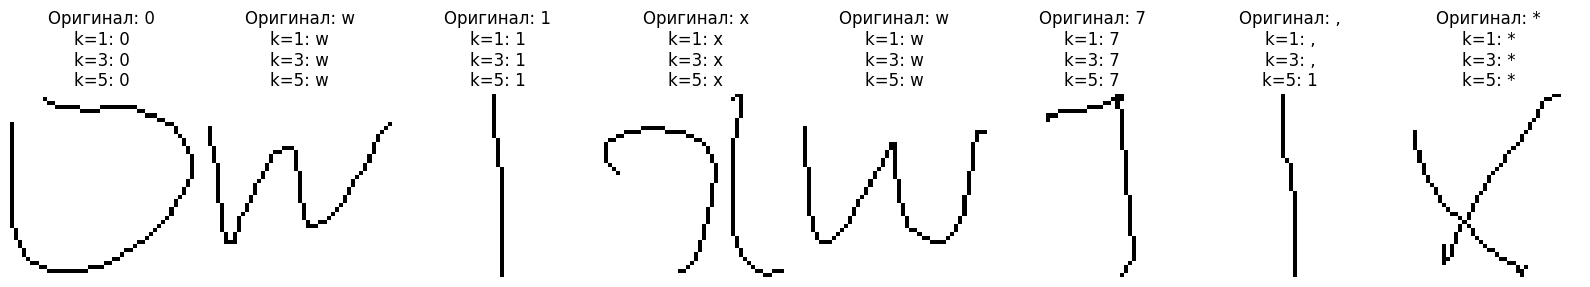

In [18]:
text, char_images = builder.build_sequence(length=8)
test_image = merge_characters(char_images, gap=20)
extracted_chars = split_into_chars(test_image)


fig, axes = plt.subplots(1, len(extracted_chars), figsize=(2*len(extracted_chars), 3))
if len(extracted_chars) == 1:
    axes = [axes]

for i, (x, img) in enumerate(extracted_chars):
    axes[i].imshow(img, cmap='gray')
    axes[i].axis('off')
    predictions = "\n".join([f"k={k}: {recognize_char(clf, img, scaler)}" 
                            for k, clf in classifiers.items()])
    axes[i].set_title(f"Оригинал: {text[i]}\n{predictions}")

plt.tight_layout()
plt.show()

In [19]:
print("Оригинальная последовательность:", text)
print("-" * 60)
for k, clf in classifiers.items():
    predicted = ''.join([recognize_char(clf, img, scaler) for _, img in extracted_chars])
    matches = sum([text[i] == predicted[i] for i in range(len(text))])
    total = len(text)
    accuracy = matches / total * 100
    print(f"knn{k:<2}| Accuracy: {accuracy:6.2f}% | {matches}/{total} | Предсказание: '{predicted}'")

Оригинальная последовательность: 0w1xw7,*
------------------------------------------------------------
knn1 | Accuracy: 100.00% | 8/8 | Предсказание: '0w1xw7,*'
knn3 | Accuracy: 100.00% | 8/8 | Предсказание: '0w1xw7,*'
knn5 | Accuracy:  87.50% | 7/8 | Предсказание: '0w1xw71*'
